# Video

Demonstrating different responses of the retinal layers to different types of motion - lateral and approaching. The lateral motion generates more spikes in the ganglion layer than does the lateral motion.

In [107]:
import typing as tp

# --------------------------------------
import torch as pt

# --------------------------------------
import numpy as np

# --------------------------------------
from functools import partial

# --------------------------------------
import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection
from matplotlib import colors

plt.ioff()

# --------------------------------------
import cv2 as cv

# --------------------------------------
from pathlib import Path

# --------------------------------------
from IPython.display import Video

# --------------------------------------
from pyrception import conf
import pyrception.visual.util.types as pct
import pyrception.util.functions as pf
from pyrception.visual.layers import ReceptorLayer
from pyrception.visual.layers import HorizontalLayer
from pyrception.visual.layers import BipolarLayer
from pyrception.visual.layers import AmacrineLayer
from pyrception.visual.layers import GanglionLayer
from pyrception.visual.util.types import ImagePlot
from pyrception.visual.util.types import ScatterPlot

In [108]:
max_frames = None

## Open and process the video files

In [109]:
def frame_generator(
    path: Path,
    max_frames: int = None,
    scale: float = None,
):

    cap = cv.VideoCapture(path)
    frame_idx = 0

    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))

    new_size = None
    if scale is not None:
        if not (0.0 < scale <= 1.0):
            raise ValueError(
                f"Invalid scale {scale} (must be a positive number in (0.0, 1.0])."
            )
        new_size = (int(width * scale), int(height * scale))

    while True:
        # Read a frame
        (processing, frame) = cap.read()

        if (
            processing is None
            or frame is None
            or (max_frames is not None and frame_idx >= max_frames)
        ):
            print("\n==[ Exiting...")
            break

        frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

        if new_size is not None:
            frame = cv.resize(frame, new_size)

        frame_idx += 1

        print(f"==[ Processing frame {frame_idx:>4d} (size: {new_size})...\r", end="")
        yield frame / frame.max()

In [110]:
lateral_motion_video_path = Path("./resources/lateral_motion.mp4")
approaching_motion_video_path = Path("./resources/approaching_motion.mp4")
if not lateral_motion_video_path.exists():
    raise FileNotFoundError(
        f"Invalid path for the lateral motion video: {lateral_motion_video_path}"
    )
if not approaching_motion_video_path.exists():
    raise FileNotFoundError(
        f"Invalid path for the approaching motion video: {approaching_motion_video_path}"
    )

lateral_motion_frames = pt.from_numpy(
    np.stack(
        [
            f
            for f in frame_generator(
                lateral_motion_video_path,
                scale=0.5,
                max_frames=max_frames,
            )
        ],
        axis=0,
    )
).to(conf.device)
approaching_motion_frames = pt.from_numpy(
    np.stack(
        [
            f
            for f in frame_generator(
                approaching_motion_video_path,
                scale=0.5,
                max_frames=max_frames,
            )
        ],
        axis=0,
    )
).to(conf.device)

==[ Processing frame  120 (size: (640, 360))...
==[ Exiting...
==[ Processing frame  120 (size: (640, 360))...
==[ Exiting...


In [111]:
(h, w) = lateral_motion_frames[0].shape
size = (h, w)

plot_kw = {}

image_kw = {}

scatter_kw = {
    "axis": True,
    "spines": True,
}

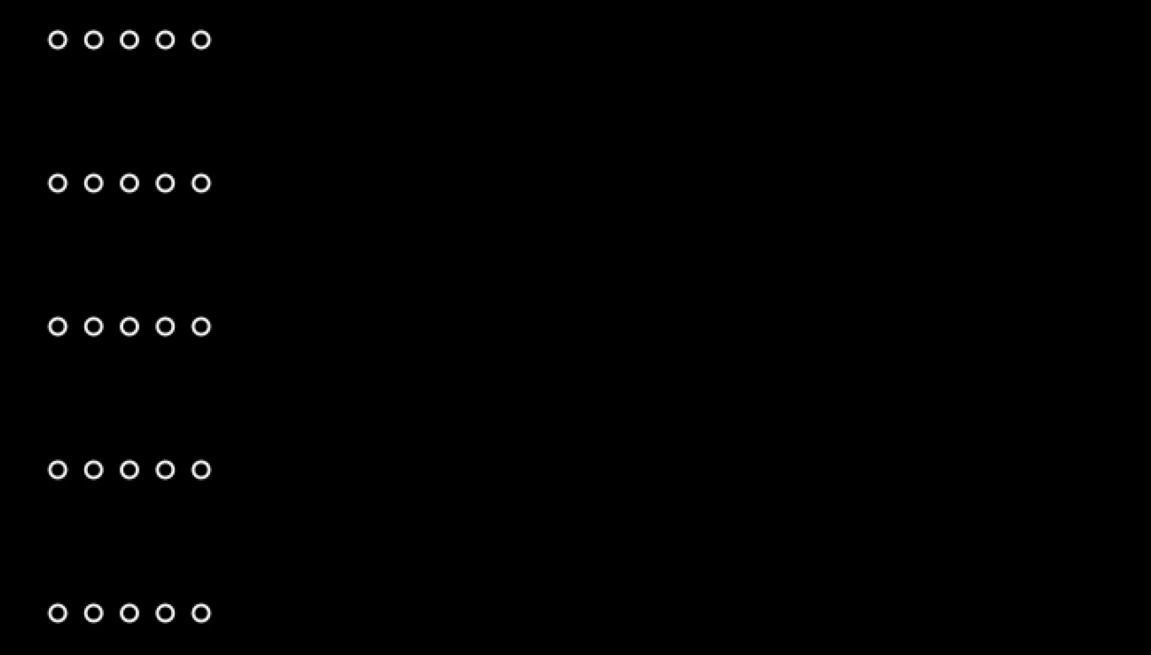

In [112]:
(fig, _, _) = pf.plot(lateral_motion_frames[0], **plot_kw)
fig

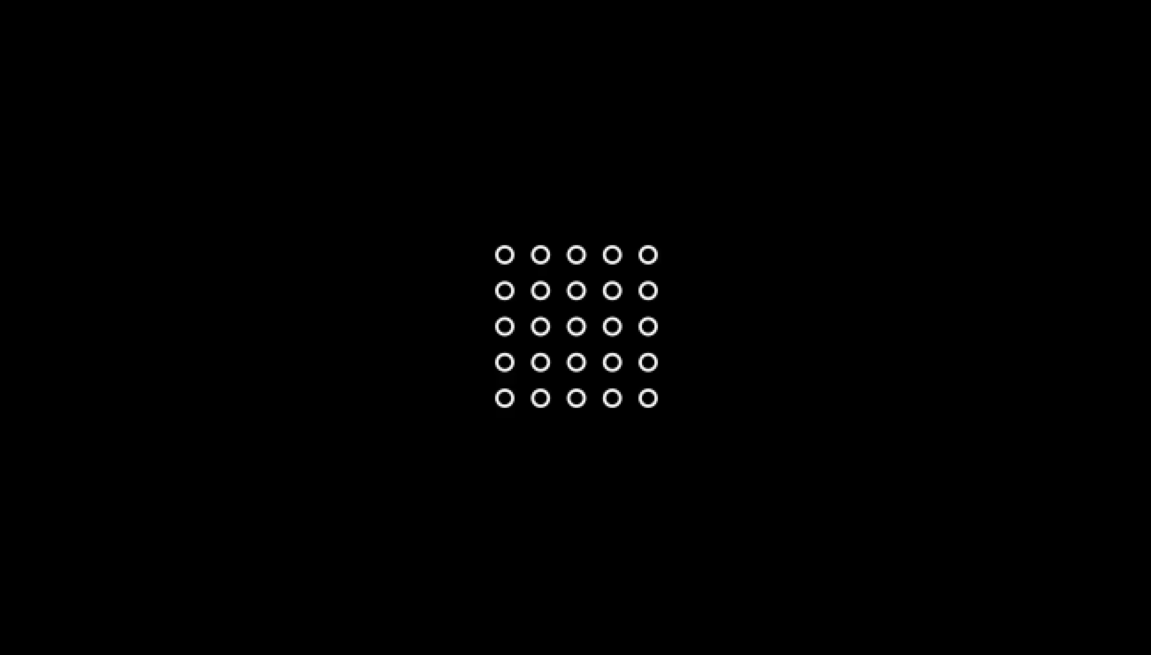

In [113]:
(fig, _, _) = pf.plot(approaching_motion_frames[0], **plot_kw)
fig

In [114]:
def implot(x: np.ndarray, **kwargs):
    kw = image_kw.copy()
    kw.update(kwargs)
    return ImagePlot(x, **kwargs)


def scatplot(x: np.ndarray, **kwargs):
    kw = image_kw.copy()
    kw.update(kwargs)
    return ScatterPlot(x, **kwargs)

## Receptor layer

In [115]:
rl_params = {
    "size": size,
}

rl = ReceptorLayer(**rl_params)

Pyrception | 2024-07-11@23:15:27 | Receptor | Initialising...
Pyrception | 2024-07-11@23:15:27 | Receptor | Initialised.


## Horizontal layer

In [116]:
hl_params = {
    "size": size,
    "receptor": rl,
    "sectors": 64,
    "rf_params": {
        "kernel_params": {
            "filter": pct.KernelFilter.Gaussian,
            "min_size": 1,
            "scale": 1.0,
        }
    },
}

hl = HorizontalLayer(**hl_params)

Pyrception | 2024-07-11@23:15:27 | Horizontal | Initialising...
Pyrception | 2024-07-11@23:15:27 | Horizontal | Horizontal RFs | Creating receptive fields...


Neurons created: 100%|██████████| 2515/2515 [00:06<00:00, 418.34it/s]


Pyrception | 2024-07-11@23:15:33 | Horizontal | Horizontal RFs | RF sparsity: 0.1035%
Pyrception | 2024-07-11@23:15:35 | Horizontal | Horizontal RFs | Receptive fields created for 2515 neurons.
Pyrception | 2024-07-11@23:15:35 | Horizontal | Initialised.


## Bipolar layer

In [117]:
bl_params = {
    "size": size,
    "receptor": rl,
    "horizontal": hl,
    "sectors": 128,
    "forgetting_range": (0.45, 0.5),
    "rf_params": {
        "kernel_params": {
            "filter": pct.KernelFilter.Uniform,
        }
    },
}

bl = BipolarLayer(**bl_params)

Pyrception | 2024-07-11@23:15:35 | Bipolar | Initialising...
Pyrception | 2024-07-11@23:15:35 | Bipolar | Bipolar RFs | Creating receptive fields...


Neurons created: 100%|██████████| 7995/7995 [00:18<00:00, 442.54it/s]


Pyrception | 2024-07-11@23:15:53 | Bipolar | Bipolar RFs | RF sparsity: 0.03555%
Pyrception | 2024-07-11@23:15:53 | Bipolar | Bipolar RFs | Receptive fields created for 7995 neurons.
Pyrception | 2024-07-11@23:15:53 | Bipolar | Forgetting rate range: 0.450 - 0.500
Pyrception | 2024-07-11@23:15:53 | Bipolar | Initialised.


## Amacrine layer

In [118]:
al_params = {
    "size": size,
    "bipolar": bl,
    "sectors": 96,
    "rf_params": {
        "kernel_params": {
            "filter": pct.KernelFilter.Uniform,
            "min_size": 3,
        }
    },
}

al = AmacrineLayer(**al_params)

Pyrception | 2024-07-11@23:15:53 | Amacrine | Initialising...
Pyrception | 2024-07-11@23:15:53 | Amacrine | Amacrine RFs | Creating receptive fields...


Neurons created: 100%|██████████| 4985/4985 [00:01<00:00, 2822.82it/s]


Pyrception | 2024-07-11@23:15:55 | Amacrine | Amacrine RFs | RF sparsity: 0.1417%
Pyrception | 2024-07-11@23:15:55 | Amacrine | Amacrine RFs | Receptive fields created for 4985 neurons.
Pyrception | 2024-07-11@23:15:55 | Amacrine | Initialised.


## Ganglion layer

In [119]:
gl_bl_params = {
    "kernel_params": {
        "scale": 1.0,
        "filter": pct.KernelFilter.Uniform,
    }
}
gl_al_params = {
    "kernel_params": {
        "scale": 2.0,
        "filter": pct.KernelFilter.Uniform,
    },
}


gl_params = {
    "size": size,
    "bipolar": bl,
    "amacrine": al,
    "sectors": 64,
    "bipolar_params": gl_bl_params,
    "amacrine_params": gl_al_params,
    "inhibition_scale": 1.5,
}


class ApproachDetectionGanglionLayer(GanglionLayer):
    def forward(self):
        """
        Implements a looming detector for approaching bright objects.
        """

        # ON centre / OFF surround

        gl_bl_on = self.convolve(
            self.bipolar_rfs.rfs,
            self.bipolar.off,
        )

        gl_al_off = self.inhibition_scale * self.convolve(
            self.amacrine_rfs.rfs,
            self.amacrine.off,
        )
        spikes = pt.where(-0.05 + gl_bl_on - gl_al_off >= 0, 1, 0)

        return spikes


gl = ApproachDetectionGanglionLayer(**gl_params)

Pyrception | 2024-07-11@23:15:55 | Ganglion | Initialising...
Pyrception | 2024-07-11@23:15:55 | Ganglion | Bipolar RFs | Creating receptive fields...


Neurons created: 100%|██████████| 2515/2515 [00:01<00:00, 1308.36it/s]

Pyrception | 2024-07-11@23:15:57 | Ganglion | Bipolar RFs | RF sparsity: 0.101%


Pyrception | 2024-07-11@23:15:57 | Ganglion | Bipolar RFs | Receptive fields created for 2515 neurons.
Pyrception | 2024-07-11@23:15:57 | Ganglion | Amacrine RFs | Creating receptive fields...


Neurons created: 100%|██████████| 2515/2515 [00:01<00:00, 2371.08it/s]

Pyrception | 2024-07-11@23:15:59 | Ganglion | Amacrine RFs | RF sparsity: 1.731%


Pyrception | 2024-07-11@23:15:59 | Ganglion | Amacrine RFs | Receptive fields created for 2515 neurons.
Pyrception | 2024-07-11@23:15:59 | Ganglion | Initialised.


Pass a single frame through all the layers and plot the results into the designated slots.

In [120]:
def process(
    frame: pt.Tensor,
    axes: plt.Axes,
    mappables: tp.List[PathCollection],
):

    # Blank canvas
    canvas = np.zeros((h, w))

    # Receptors
    # ==================================================
    rl.forward(frame)

    # Plot the raw input
    mappables[0].set_data(frame)
    mappables[0].set_clim(frame.min(), frame.max())

    # Horizontal cells
    # ==================================================
    (hl_activation, hl_feedback) = hl.forward()
    hl_feedback = hl_feedback.reshape(hl.rfs.height, hl.rfs.width)

    # Plot the activation of the horizontal cells
    hl_activation_canvas = canvas.copy()
    hl_activation_canvas[hl.rfs.cell_coordinates[:, 0], hl.rfs.cell_coordinates[:, 1]] = hl_activation
    mappables[1].set_data(hl_activation_canvas)
    mappables[1].set_clim(hl_activation_canvas.min(), hl_activation_canvas.max())

    # Plot the feedback signal (mean illumination map)
    mappables[2].set_data(hl_feedback)
    mappables[2].set_clim(hl_feedback.min(), hl_feedback.max())

    # Plot the scaled input
    scaled = frame - hl_feedback
    mappables[3].set_data(scaled)
    mappables[3].set_clim(scaled.min(), scaled.max())

    # Bipolar cells
    # ==================================================
    (bl_on, bl_off, scaled, bp_activation) = bl.forward()

    # Plot the activation of ON and OFF bipolar cells
    bl_on_canvas = canvas.copy()
    bl_off_canvas = canvas.copy()

    bl_on_canvas[bl.rfs.cell_coordinates[:, 0], bl.rfs.cell_coordinates[:, 1]] = bl_on
    bl_off_canvas[bl.rfs.cell_coordinates[:, 0], bl.rfs.cell_coordinates[:, 1]] = bl_off

    mappables[4].set_data(bl_on_canvas)
    mappables[4].set_clim(bl_on_canvas.min(), bl_on_canvas.max())

    mappables[5].set_data(bl_off_canvas)
    mappables[5].set_clim(bl_off_canvas.min(), bl_off_canvas.max())

    # Amacrine cells
    # ==================================================
    (al_on, al_off) = al.forward()

    # Plot the activation of ON and OFF amarcine cells
    al_on_canvas = canvas.copy()
    al_off_canvas = canvas.copy()

    al_on_canvas[al.rfs.cell_coordinates[:, 0], al.rfs.cell_coordinates[:, 1]] = al_on
    al_off_canvas[al.rfs.cell_coordinates[:, 0], al.rfs.cell_coordinates[:, 1]] = al_off

    mappables[6].set_data(al_on_canvas)
    mappables[6].set_clim(al_on_canvas.min(), al_on_canvas.max())

    mappables[7].set_data(al_off_canvas)
    mappables[7].set_clim(al_off_canvas.min(), al_off_canvas.max())

    # Ganglion cells
    # ==================================================
    gl_spikes = gl.forward()

    # Plot the activation of ON-centre and OFF-centre ganglion cells
    gl_canvas = canvas.copy()

    gl_canvas[gl.bipolar_rfs.cell_coordinates[:, 0], gl.bipolar_rfs.cell_coordinates[:, 1]] = gl_spikes

    mappables[8].set_data(gl_canvas)
    mappables[8].set_clim(0, 1)


In [121]:
def animator(
    frame: pt.Tensor,
    axes: plt.Axes,
    mappables: tp.List[PathCollection],
):

    process(frame, axes, mappables)
    return mappables

A simple frame iterator - used by the animation routine.

In [122]:
def frame_iterator(frames: pt.Tensor):
    for frame_idx, frame in enumerate(frames):

        print(f"==[ Processing frame {frame_idx:>5d}...\r", end="")
        yield frame

Make a plot grid for the input and all layers

In [123]:
def make_plot_grid(title: str = "Retinomorphic processing pipeline"):

    init_frame = pt.randn((h, w)) / 100

    (fig, axes, mappables) = pf.plot(
        [
            [
                implot(init_frame, title="Raw input"),
                implot(init_frame, title="Horizontal cell activity", cmap="hot"),
                implot(
                    init_frame, title="Horizontal cell feedback (mean illumination map)"
                ),
            ],
            [
                implot(init_frame, title="Scaled raw input"),
                implot(
                    init_frame, title="ON bipolar", cmap="hot", norm=colors.LogNorm()
                ),
                implot(
                    init_frame, title="OFF bipolar", cmap="hot", norm=colors.LogNorm()
                ),
            ],
            [
                implot(init_frame, title="ON-driven amacrine", cmap="hot"),
                implot(init_frame, title="OFF-driven amacrine", cmap="hot"),
                implot(init_frame, title="Ganglion"),
            ],
        ],
        figsize=(16, 8),
        title=title,
    )

    return (fig, axes, mappables)

In [124]:
fps = 25
video_format = "mp4"

In [125]:
# Animation - lateral motion
# ==================================================
(fig_lat, axes_lat, mappables_lat) = make_plot_grid()
_, filename_lateral_motion = pf.animate(
    fig_lat,
    partial(animator, axes=axes_lat, mappables=mappables_lat),
    partial(frame_iterator, lateral_motion_frames.type(pt.float32)),
    title="Retina response - lateral motion",
    fps=fps,
    output_dir="./output/lateral_motion",
    format=video_format,
)

==[ Error: mat2 must be a matrix, got 1-D tensor


In [126]:
Video(filename_lateral_motion)

In [127]:
# Animation - approaching motion
# ==================================================
(fig_app, axes_app, mappables_app) = make_plot_grid()
ani, filename_approaching_motion = pf.animate(
    fig_app,
    partial(animator, axes=axes_app, mappables=mappables_app),
    partial(frame_iterator, approaching_motion_frames.type(pt.float32)),
    title="Retina response - approaching motion",
    fps=fps,
    output_dir="./output/approaching_motion",
    format=video_format,
)

==[ Error: mat2 must be a matrix, got 1-D tensor


In [128]:
Video(filename_approaching_motion)